# 🏦 FinBERT Fine-Tuning — Indian Stock Market Sentiment
### Multi-Agent Financial Advisor | Signal Translator (v2)

**Complete Pipeline:**
1. Install & Setup
2. Load & Preprocess CSV
3. Handle Class Imbalance
4. Fine-Tune FinBERT (Steps 4–9)
5. NSE Entity Extraction · Temporal Decay · Impact Type · Signal Logic (Steps 10–13)
6. Enhanced Batch Inference → CSV output (Step 14)
7. Signal Analysis Charts (Step 15)
8. FastAPI Real-Time Endpoint (Step 16)
9. Live Demo Test (Step 17)

> ⚡ Runtime → Change runtime type → **T4 GPU** before running

## 📦 Step 1 — Install Dependencies

In [21]:
%%capture
!pip install transformers datasets scikit-learn torch torchvision
!pip install fastapi uvicorn pyngrok nest-asyncio
!pip install seaborn matplotlib spacy pytz
!python -m spacy download en_core_web_sm

## ☁️ Step 2 — Mount Google Drive & Load Dataset

In [22]:
import pandas as pd
df = pd.read_csv('final_labeled_project_data.csv')

print(f'Total rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total rows loaded: 2760
Columns: ['source', 'source_type', 'title', 'text', 'url', 'published', 'collected_at', 'full_text', 'auto_sentiment', 'manual_sentiment']


,source,source_type,title,text,url,published,collected_at,full_text,auto_sentiment,manual_sentiment
0,Moneycontrol,news,"Buy HDFC Bank; target of Rs 1,850: ICICI Secur...",ICICI Securities is bullish on HDFC Bank has ...,https://www.moneycontrol.com/news/recommendati...,"Tue, 23 Apr 2024 13:41:02 +0530",2026-02-10T14:49:06.279092,"Buy HDFC Bank; target of Rs 1,850: ICICI Secur...",Neutral,Positive
1,Moneycontrol,news,Buy Tejas Networks; target of Rs 1100: Emkay G...,Emkay Global Financial is bullish on Tejas Ne...,https://www.moneycontrol.com/news/recommendati...,"Tue, 23 Apr 2024 13:36:47 +0530",2026-02-10T14:49:06.279092,Buy Tejas Networks; target of Rs 1100: Emkay G...,Neutral,Positive
2,Moneycontrol,news,Buy Bajaj Finance; target of Rs 9000: Emkay Gl...,Emkay Global Financial is bullish on Bajaj Fi...,https://www.moneycontrol.com/news/recommendati...,"Tue, 23 Apr 2024 13:36:44 +0530",2026-02-10T14:49:06.279092,Buy Bajaj Finance; target of Rs 9000: Emkay Gl...,Neutral,Positive
3,Moneycontrol,news,Buy Bajaj Finance; target of Rs 9000: Emkay Gl...,Emkay Global Financial is bullish on Bajaj Fi...,https://www.moneycontrol.com/news/recommendati...,"Tue, 23 Apr 2024 13:36:44 +0530",2026-02-10T14:49:06.279092,Buy Bajaj Finance; target of Rs 9000: Emkay Gl...,Neutral,Positive
4,Moneycontrol,news,Reduce Persistent Systems; target of Rs 3700: ...,Emkay Global Financial recommended reduce rat...,https://www.moneycontrol.com/news/recommendati...,"Tue, 23 Apr 2024 13:26:31 +0530",2026-02-10T14:49:06.279092,Reduce Persistent Systems; target of Rs 3700: ...,Neutral,Negative


## 🧹 Step 3 — Preprocess & Label Strategy

In [23]:
# Use manual_sentiment where available, fall back to auto_sentiment
df['final_sentiment'] = df['manual_sentiment'].fillna(df['auto_sentiment'])

# Standardize labels (strip whitespace, capitalize)
df['final_sentiment'] = df['final_sentiment'].str.strip().str.capitalize()

# Keep only rows with valid labels
valid_labels = ['Positive', 'Negative', 'Neutral']
df = df[df['final_sentiment'].isin(valid_labels)].reset_index(drop=True)

# Use 'title' as input text (your headlines are short < 20 words)
# If title is empty, fall back to full_text
df['input_text'] = df['title'].fillna(df['full_text']).astype(str).str.strip()

# Remove empty texts
df = df[df['input_text'].str.len() > 3].reset_index(drop=True)

print(f'\nClean dataset size: {len(df)}')
print(f'\nLabel Distribution:')
print(df['final_sentiment'].value_counts())
print(f'\nDistribution %:')
print(df['final_sentiment'].value_counts(normalize=True).mul(100).round(1))


Clean dataset size: 2759

Label Distribution:
final_sentiment
Positive    1109
Neutral     1017
Negative     633
Name: count, dtype: int64

Distribution %:
final_sentiment
Positive    40.2
Neutral     36.9
Negative    22.9
Name: proportion, dtype: float64


## ⚖️ Step 4 — Handle Class Imbalance (Critical for 60%+ Neutral)

In [24]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Label encoding
LABEL2ID = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# Score mapping for agent output (-1 to 1)
LABEL2SCORE = {'Positive': 1.0, 'Negative': -1.0, 'Neutral': 0.0}

df['label'] = df['final_sentiment'].map(LABEL2ID)

# Compute class weights to penalize the model for ignoring minority classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df['label'].values
)
class_weights = dict(enumerate(class_weights))
print(f'Class weights (to counter imbalance):')
for label_id, weight in class_weights.items():
    print(f'  {ID2LABEL[label_id]}: {weight:.4f}')
print('\n⚠  Higher weight = model penalized MORE for missing that class')

Class weights (to counter imbalance):
  Positive: 0.8293
  Negative: 1.4529
  Neutral: 0.9043

⚠  Higher weight = model penalized MORE for missing that class


## ✂️ Step 5 — Train / Validation / Test Split

In [25]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve class ratios in each set
train_df, temp_df = train_test_split(
    df[['input_text', 'label', 'final_sentiment']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train size : {len(train_df)}')
print(f'Val size   : {len(val_df)}')
print(f'Test size  : {len(test_df)}')

Train size : 2207
Val size   : 276
Test size  : 276


## 🔃 Fix 1 — Under-Sampling the Neutral Majority
> Caps Neutral at 1.5x minority class — runs BEFORE training so model trains on balanced data

In [ ]:
import pandas as pd
import numpy as np

print('Label distribution BEFORE under-sampling:')
print(train_df['final_sentiment'].value_counts())
print()

# ── Find the size of the smallest class ───────────────────────────────────
min_class_size = train_df['final_sentiment'].value_counts().min()

# Target: Neutral gets capped at 1.5x the minority class
# (fully equalizing can lose too much neutral signal for Indian market)
neutral_cap = int(min_class_size * 1.5)

neutral_df   = train_df[train_df['final_sentiment'] == 'Neutral'].sample(
                    n=min(neutral_cap, len(train_df[train_df['final_sentiment'] == 'Neutral'])),
                    random_state=42
               )
positive_df  = train_df[train_df['final_sentiment'] == 'Positive']
negative_df  = train_df[train_df['final_sentiment'] == 'Negative']

train_df_balanced = pd.concat([positive_df, negative_df, neutral_df]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print('Label distribution AFTER under-sampling:')
print(train_df_balanced['final_sentiment'].value_counts())
print(f'\nTotal training rows: {len(train_df)} → {len(train_df_balanced)}')
print('\n✅ Neutral bias reduced — model can no longer cheat by always guessing Neutral')

## 🔄 Fix 2 — Synthetic Augmentation (Synonym Replacement)
> Doubles Positive/Negative examples using Indian financial synonyms — no internet needed

In [ ]:
import random

# ── Synonym dictionary for Indian financial terms ─────────────────────────
# Back-translation would need internet — this synonym replacement works offline
SYNONYMS = {
    'surges'    : ['rallies', 'jumps', 'climbs', 'gains', 'rises'],
    'crashes'   : ['collapses', 'plunges', 'tumbles', 'falls', 'drops'],
    'rises'     : ['increases', 'gains', 'advances', 'climbs', 'surges'],
    'falls'     : ['declines', 'drops', 'slides', 'dips', 'retreats'],
    'profit'    : ['earnings', 'net income', 'surplus', 'gains'],
    'loss'      : ['deficit', 'shortfall', 'decline', 'negative earnings'],
    'record'    : ['all-time high', 'historic', 'unprecedented', 'peak'],
    'hikes'     : ['raises', 'increases', 'lifts', 'bumps up'],
    'cuts'      : ['reduces', 'slashes', 'lowers', 'trims'],
    'strong'    : ['robust', 'solid', 'healthy', 'impressive'],
    'weak'      : ['poor', 'sluggish', 'disappointing', 'soft'],
    'quarterly' : ['Q1', 'Q2', 'Q3', 'Q4', 'three-month'],
    'investors' : ['traders', 'market participants', 'shareholders'],
    'points'    : ['pts', 'basis points'],
    'percent'   : ['%', 'per cent'],
    'crore'     : ['cr', '10 million'],
}

def augment_headline(headline: str, n_augments: int = 1) -> list:
    """Generate n augmented versions of a headline by random synonym replacement."""
    augmented = []
    for _ in range(n_augments):
        words  = headline.split()
        new_words = []
        changed = False
        for word in words:
            word_lower = word.lower().rstrip('.,;')
            if word_lower in SYNONYMS and random.random() > 0.4:
                new_words.append(random.choice(SYNONYMS[word_lower]))
                changed = True
            else:
                new_words.append(word)
        # Only add if something actually changed
        if changed:
            augmented.append(' '.join(new_words))
    return augmented

# ── Augment only minority classes (Positive and Negative) ─────────────────
augmented_rows = []

for _, row in train_df_balanced.iterrows():
    if row['final_sentiment'] in ['Positive', 'Negative']:
        new_headlines = augment_headline(row['input_text'], n_augments=2)
        for nh in new_headlines:
            augmented_rows.append({
                'input_text'      : nh,
                'final_sentiment' : row['final_sentiment'],
                'label'           : row['label']
            })

augmented_df = pd.DataFrame(augmented_rows)
train_df_final = pd.concat([train_df_balanced, augmented_df]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print('Label distribution AFTER augmentation:')
print(train_df_final['final_sentiment'].value_counts())
print(f'\nFinal training rows: {len(train_df_balanced)} → {len(train_df_final)}')
print('\n✅ Minority classes doubled — model sees more Positive/Negative examples')

# Use this as your training data from here
train_df = train_df_final

## ⚖️ Fix 3 — Recompute Class Weights on Balanced Data
> Updates loss function with new balanced weights — must run before training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Recompute weights on the NEW balanced+augmented training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label'].values
)
class_weights = dict(enumerate(class_weights))

ID2LABEL = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

print('Recomputed class weights after balancing:')
for label_id, weight in class_weights.items():
    print(f'  {ID2LABEL[label_id]}: {weight:.4f}')

weights_tensor = torch.tensor(
    [class_weights[0], class_weights[1], class_weights[2]],
    dtype=torch.float
).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor)
print('\n✅ Loss function updated with new balanced weights')

## 🤗 Step 6 — Load FinBERT Tokenizer & Model

In [26]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = 'ProsusAI/finbert'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True   # We're redefining the classification head
)
model = model.to(device)
print('\n✅ FinBERT loaded successfully')

Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ FinBERT loaded successfully


## 📊 Step 7 — Build PyTorch Dataset

In [27]:
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len   # Headlines are short, 64 is more than enough

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 32

train_dataset = SentimentDataset(train_df['input_text'].tolist(), train_df['label'].tolist(), tokenizer)
val_dataset   = SentimentDataset(val_df['input_text'].tolist(),   val_df['label'].tolist(),   tokenizer)
test_dataset  = SentimentDataset(test_df['input_text'].tolist(),  test_df['label'].tolist(),  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

Train batches: 69
Val batches  : 9


## 🏋️ Step 8 — Fine-Tune with Class-Weighted Loss

In [28]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS       = 4
LEARNING_RATE = 2e-5

# Weighted loss — punishes model harder for misclassifying minority classes
weights_tensor = torch.tensor(
    [class_weights[0], class_weights[1], class_weights[2]],
    dtype=torch.float
).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask      = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=mask)
            loss      = loss_fn(outputs.logits, labels)
            preds     = torch.argmax(outputs.logits, dim=1)
            total_loss += loss.item()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

# ── Training Loop ─────────────────────────────────────────────────────────
best_val_acc = 0
history = []

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        mask      = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(outputs.logits, dim=1)
        train_loss    += loss.item()
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    train_acc = train_correct / train_total
    val_loss, val_acc, _, _ = evaluate(val_loader)

    history.append({'epoch': epoch+1, 'train_acc': train_acc, 'val_acc': val_acc})
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained('/content/drive/MyDrive/finbert_indian_best')
        tokenizer.save_pretrained('/content/drive/MyDrive/finbert_indian_best')
        print(f'  ✅ Best model saved (Val Acc: {val_acc:.4f})')

print(f'\n🏆 Best Validation Accuracy: {best_val_acc:.4f}')

Epoch 1/4 | Train Acc: 0.7000 | Val Acc: 0.7174 | Val Loss: 0.6649


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (Val Acc: 0.7174)
Epoch 2/4 | Train Acc: 0.8024 | Val Acc: 0.7681 | Val Loss: 0.6229


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (Val Acc: 0.7681)
Epoch 3/4 | Train Acc: 0.8777 | Val Acc: 0.7717 | Val Loss: 0.6368


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (Val Acc: 0.7717)
Epoch 4/4 | Train Acc: 0.9076 | Val Acc: 0.7899 | Val Loss: 0.6388


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (Val Acc: 0.7899)

🏆 Best Validation Accuracy: 0.7899


## 📈 Step 9 — Evaluate on Test Set (Accuracy, F1, Confusion Matrix)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  TEST ACCURACY : 0.7899 (78.99%)

Classification Report:
              precision    recall  f1-score   support

    Positive       0.83      0.91      0.87       111
    Negative       0.72      0.73      0.73        64
     Neutral       0.78      0.69      0.73       101

    accuracy                           0.79       276
   macro avg       0.78      0.78      0.78       276
weighted avg       0.79      0.79      0.79       276



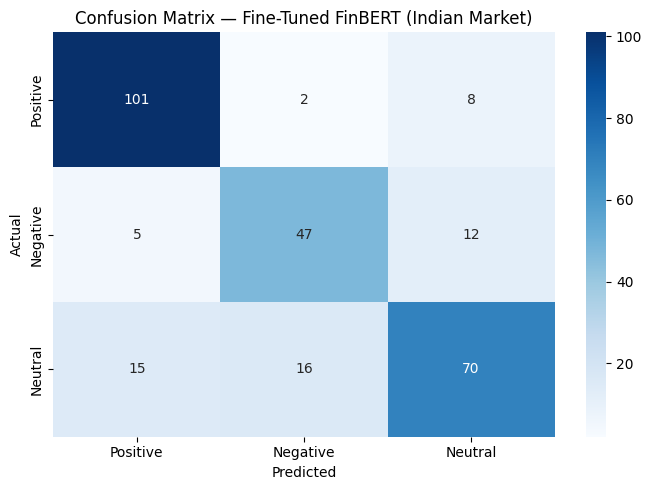

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model for final evaluation
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/finbert_indian_best').to(device)

_, test_acc, test_preds, test_labels = evaluate(test_loader)

print('=' * 55)
print(f'  TEST ACCURACY : {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 55)

label_names = ['Positive', 'Negative', 'Neutral']
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — Fine-Tuned FinBERT (Indian Market)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Run predictions on test set ───────────────────────────────────────────
test_texts  = test_df['input_text'].tolist()
test_labels = test_df['label'].tolist()
test_preds_raw = predict_with_confidence_filter(test_texts)

ID2LABEL_FULL = {0: 'Positive', 1: 'Negative', 2: 'Neutral', 'Ambiguous': 3}
LABEL2ID = {'Positive': 0, 'Negative': 1, 'Neutral': 2}

# Map ambiguous back to predicted class for metrics
test_preds = []
for r in test_preds_raw:
    label = r['label']
    if label == 'Ambiguous':
        # Use the highest prob class even if low confidence
        probs = r['all_probs']
        label = max(probs, key=probs.get)
    test_preds.append(LABEL2ID[label])

label_names = ['Positive', 'Negative', 'Neutral']

# ── 1. Classification Report ──────────────────────────────────────────────
print('='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(test_labels, test_preds, target_names=label_names))

# ── 2. Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — Fine-Tuned FinBERT (Indian Market)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── 3. Error Analysis — show what the model got WRONG ─────────────────────
print('\n' + '='*60)
print('ERROR ANALYSIS — Headlines the Model Got Wrong')
print('='*60)

error_rows = []
for i, (true, pred, raw) in enumerate(zip(test_labels, test_preds, test_preds_raw)):
    if true != pred:
        error_rows.append({
            'headline'         : test_texts[i],
            'actual'           : label_names[true],
            'predicted'        : label_names[pred],
            'confidence'       : raw['confidence'],
            'confidence_tier'  : raw['confidence_tier'],
            'prob_positive'    : raw['all_probs']['Positive'],
            'prob_negative'    : raw['all_probs']['Negative'],
            'prob_neutral'     : raw['all_probs']['Neutral'],
        })

error_df = pd.DataFrame(error_rows)

print(f'Total errors: {len(error_df)} / {len(test_labels)} ({len(error_df)/len(test_labels)*100:.1f}%)')

print(f'\nError breakdown by type:')
print(error_df.groupby(['actual', 'predicted']).size().to_string())

print(f'\nTop 10 Most Confident WRONG predictions (model was sure but still wrong):')
print('-'*100)
top_errors = error_df.sort_values('confidence', ascending=False).head(10)
for _, row in top_errors.iterrows():
    print(f"  Headline  : {row['headline']}")
    print(f"  Actual    : {row['actual']:<12} Predicted: {row['predicted']:<12} Confidence: {row['confidence']:.4f}")
    print(f"  Probs     : Positive={row['prob_positive']:.3f}  Negative={row['prob_negative']:.3f}  Neutral={row['prob_neutral']:.3f}")
    print()

# ── 4. Pattern Detection in Errors ───────────────────────────────────────
print('='*60)
print('ERROR PATTERN DETECTION')
print('='*60)

# Check for Indian financial terms in errors
indian_terms  = ['lakh', 'crore', 'sensex', 'nifty', 'sebi', 'rbi', 'rupee', 'bse', 'nse']
sarcasm_hints = ['despite', 'although', 'even though', 'surprisingly', 'unexpectedly', 'ironically']

indian_errors  = error_df[error_df['headline'].str.lower().str.contains('|'.join(indian_terms))]
sarcasm_errors = error_df[error_df['headline'].str.lower().str.contains('|'.join(sarcasm_hints))]

print(f'  Errors involving Indian market terms : {len(indian_errors)} ({len(indian_errors)/len(error_df)*100:.1f}% of errors)')
print(f'  Errors involving sarcasm/contrast    : {len(sarcasm_errors)} ({len(sarcasm_errors)/len(error_df)*100:.1f}% of errors)')
print(f'  Low confidence errors (< 0.60)       : {len(error_df[error_df["confidence_tier"] == "LOW"])} (safety brake would catch these)')

# Save error analysis
error_df.to_csv('error_analysis.csv', index=False)
print('\n✅ Full error analysis saved to error_analysis.csv')

NameError: name 'predict_with_confidence_filter' is not defined

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

accuracy  = accuracy_score(test_labels, test_preds)
f1_macro  = f1_score(test_labels, test_preds, average='macro')
f1_weighted = f1_score(test_labels, test_preds, average='weighted')
precision = precision_score(test_labels, test_preds, average='macro')
recall    = recall_score(test_labels, test_preds, average='macro')

# Per-class F1
f1_per_class = f1_score(test_labels, test_preds, average=None)

# Ambiguous rate — how often did the safety brake fire?
ambiguous_count = sum(1 for r in test_preds_raw if r['confidence_tier'] == 'LOW')
ambiguous_rate  = ambiguous_count / len(test_preds_raw)

print('='*55)
print('  FINAL MODEL PERFORMANCE REPORT')
print('='*55)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  F1 Score (Macro)  : {f1_macro:.4f}')
print(f'  F1 Score (Weighted): {f1_weighted:.4f}')
print(f'  Precision (Macro) : {precision:.4f}')
print(f'  Recall (Macro)    : {recall:.4f}')
print('-'*55)
print(f'  F1 — Positive     : {f1_per_class[0]:.4f}')
print(f'  F1 — Negative     : {f1_per_class[1]:.4f}')
print(f'  F1 — Neutral      : {f1_per_class[2]:.4f}')
print('-'*55)
print(f'  Ambiguous Rate    : {ambiguous_rate:.2%}  (safety brake fired)')
print(f'  Error Rate        : {1-accuracy:.2%}')
print('='*55)

# Visual bar chart of metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinBERT Performance — Indian Market Sentiment', fontsize=13, fontweight='bold')

# Overall metrics
metrics = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall']
values  = [accuracy, f1_macro, f1_weighted, precision, recall]
colors  = ['#1565C0', '#6A1B9A', '#00695C', '#E65100', '#37474F']
bars = axes[0].bar(metrics, values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Overall Metrics')
axes[0].set_ylabel('Score')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Per-class F1
class_colors = ['#00C853', '#D50000', '#FFD600']
bars2 = axes[1].bar(label_names, f1_per_class, color=class_colors, edgecolor='white', width=0.4)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1 Score Per Class')
axes[1].set_ylabel('F1 Score')
for bar, val in zip(bars2, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Performance dashboard saved to model_performance.png')

---
## 🚀 Enhanced Signal Translator — Steps 10–17

## 🏢 Step 10 — NSE Ticker Dictionary (Top 100 + spaCy Fallback)

In [ ]:
# ── NSE Ticker Dictionary ─────────────────────────────────────────────────
# Dictionary-first: catches known companies deterministically
# Format: 'keyword in headline (lowercase)' → 'NSE ticker'

NSE_TICKER_DICT = {
    # Index
    'sensex'          : 'INDEX:SENSEX',
    'nifty'           : 'INDEX:NIFTY50',
    'nifty50'         : 'INDEX:NIFTY50',
    'nifty bank'      : 'INDEX:BANKNIFTY',
    'bank nifty'      : 'INDEX:BANKNIFTY',

    # Large Cap
    'reliance'        : 'RELIANCE',
    'tcs'             : 'TCS',
    'infosys'         : 'INFY',
    'wipro'           : 'WIPRO',
    'hdfc bank'       : 'HDFCBANK',
    'hdfc'            : 'HDFC',
    'icici'           : 'ICICIBANK',
    'sbi'             : 'SBIN',
    'state bank'      : 'SBIN',
    'kotak'           : 'KOTAKBANK',
    'axis bank'       : 'AXISBANK',
    'bajaj finance'   : 'BAJFINANCE',
    'bajaj finserv'   : 'BAJAJFINSV',
    'hcl'             : 'HCLTECH',
    'tech mahindra'   : 'TECHM',
    'larsen'          : 'LT',
    'l&t'             : 'LT',
    'ultratech'       : 'ULTRACEMCO',
    'asian paints'    : 'ASIANPAINT',
    'titan'           : 'TITAN',
    'nestle'          : 'NESTLEIND',
    'hindustan unilever': 'HINDUNILVR',
    'hul'             : 'HINDUNILVR',
    'itc'             : 'ITC',
    'maruti'          : 'MARUTI',
    'tata motors'     : 'TATAMOTORS',
    'tata steel'      : 'TATASTEEL',
    'tata power'      : 'TATAPOWER',
    'tata consultancy': 'TCS',
    'sun pharma'      : 'SUNPHARMA',
    'dr reddy'        : 'DRREDDY',
    'cipla'           : 'CIPLA',
    'divis'           : 'DIVISLAB',
    'ongc'            : 'ONGC',
    'ntpc'            : 'NTPC',
    'power grid'      : 'POWERGRID',
    'coal india'      : 'COALINDIA',
    'bharat petroleum': 'BPCL',
    'bpcl'            : 'BPCL',
    'ioc'             : 'IOC',
    'indian oil'      : 'IOC',
    'grasim'          : 'GRASIM',
    'britannia'       : 'BRITANNIA',
    'hero motocorp'   : 'HEROMOTOCO',
    'bajaj auto'      : 'BAJAJ-AUTO',
    'eicher'          : 'EICHERMOT',
    'royal enfield'   : 'EICHERMOT',
    'hindalco'        : 'HINDALCO',
    'jswsteel'        : 'JSWSTEEL',
    'jsw steel'       : 'JSWSTEEL',
    'vedanta'         : 'VEDL',
    'shree cement'    : 'SHREECEM',
    'apollo hospitals': 'APOLLOHOSP',
    'dmart'           : 'DMART',
    'avenue supermarts': 'DMART',
    'indusind'        : 'INDUSINDBK',

    # Adani Group
    'adani enterprises': 'ADANIENT',
    'adani ports'     : 'ADANIPORTS',
    'adani green'     : 'ADANIGREEN',
    'adani power'     : 'ADANIPOWER',
    'adani transmission': 'ADANITRANS',
    'adani total gas' : 'ATGL',
    'adani wilmar'    : 'AWL',
    'adani'           : 'ADANIENT',   # generic fallback for Adani group

    # Macro entities (not stocks but important)
    'rbi'             : 'MACRO:RBI',
    'reserve bank'    : 'MACRO:RBI',
    'sebi'            : 'MACRO:SEBI',
    'government'      : 'MACRO:GOVT',
    'finance ministry': 'MACRO:GOVT',
    'fii'             : 'MACRO:FII',
    'dii'             : 'MACRO:DII',
    'repo rate'       : 'MACRO:RBI',
    'gdp'             : 'MACRO:ECONOMY',
    'inflation'       : 'MACRO:ECONOMY',
    'crude'           : 'MACRO:CRUDE',
    'rupee'           : 'MACRO:FOREX',
    'dollar'          : 'MACRO:FOREX',
}

# ── spaCy NER fallback ────────────────────────────────────────────────────
import spacy
nlp = spacy.load('en_core_web_sm')

def extract_entity(headline: str) -> str:
    """
    1. Check NSE_TICKER_DICT first (deterministic, fast)
    2. Fall back to spaCy NER for unknown companies
    3. Return 'UNKNOWN' if nothing found
    """
    headline_lower = headline.lower()

    # Dictionary pass — longest match wins (to avoid 'hdfc' matching before 'hdfc bank')
    matches = [
        (keyword, ticker)
        for keyword, ticker in NSE_TICKER_DICT.items()
        if keyword in headline_lower
    ]
    if matches:
        best = max(matches, key=lambda x: len(x[0]))  # longest keyword = most specific
        return best[1]

    # spaCy NER fallback — extract ORG entities
    doc = nlp(headline)
    orgs = [ent.text.upper() for ent in doc.ents if ent.label_ == 'ORG']
    if orgs:
        return f'NER:{orgs[0]}'  # Prefix NER: so agent knows it's not a verified ticker

    return 'UNKNOWN'

# Quick test
test_cases = [
    'Sensex surges 1200 points as FII inflows hit record high',
    'RBI hikes repo rate by 50 bps amid rising inflation',
    'Adani Group stocks crash after Hindenburg report',
    'HDFC Bank reports record Q3 profit of 16500 crore',
    'Nifty50 closes flat in volatile session',
]
print('Entity Extraction Test:')
for t in test_cases:
    print(f'  {t[:55]:<55} → {extract_entity(t)}')

## ⏱️ Step 11 — Temporal Decay (Exponential, IST-Aware)

In [ ]:
import math
import pandas as pd
from datetime import datetime, timezone
import pytz

IST = pytz.timezone('Asia/Kolkata')

# Decay constant — controls how fast news becomes stale
# λ = 0.5 means: after 4 hours → weight ≈ 0.13 (nearly stale)
# Adjust λ higher to make news go stale faster
DECAY_LAMBDA = 0.5

# Thresholds for staleness label
DECAY_THRESHOLDS = {
    'FRESH'   : 0.80,   # < ~27 minutes old
    'RECENT'  : 0.50,   # < ~1.4 hours old
    'AGING'   : 0.20,   # < ~3.2 hours old
    'STALE'   : 0.0,    # anything older
}

def compute_decay(timestamp_str: str) -> dict:
    """
    Args:
        timestamp_str: ISO format timestamp string from 'published' or 'collected_at'
    Returns:
        {'decay_weight': float, 'hours_elapsed': float, 'freshness': str}
    """
    try:
        # Parse timestamp — handle both tz-aware and naive
        ts = pd.to_datetime(timestamp_str)
        if ts.tzinfo is None:
            ts = IST.localize(ts)   # Assume IST if no timezone info
        else:
            ts = ts.astimezone(IST)

        now_ist     = datetime.now(IST)
        hours_elapsed = (now_ist - ts).total_seconds() / 3600
        hours_elapsed = max(0, hours_elapsed)  # No negative time

        # Exponential decay: weight = e^(-λ × hours)
        decay_weight = math.exp(-DECAY_LAMBDA * hours_elapsed)
        decay_weight = round(min(1.0, max(0.0, decay_weight)), 4)

        # Freshness label
        if decay_weight >= DECAY_THRESHOLDS['FRESH']:
            freshness = 'FRESH'
        elif decay_weight >= DECAY_THRESHOLDS['RECENT']:
            freshness = 'RECENT'
        elif decay_weight >= DECAY_THRESHOLDS['AGING']:
            freshness = 'AGING'
        else:
            freshness = 'STALE'

        return {
            'decay_weight'  : decay_weight,
            'hours_elapsed' : round(hours_elapsed, 2),
            'freshness'     : freshness
        }

    except Exception:
        # If timestamp is unparseable, treat as stale
        return {'decay_weight': 0.0, 'hours_elapsed': -1, 'freshness': 'UNKNOWN'}

# Test with sample timestamps
from datetime import timedelta
now = datetime.now(IST)
print('Temporal Decay Test:')
for mins in [5, 30, 60, 120, 240, 480]:
    ts = (now - timedelta(minutes=mins)).isoformat()
    result = compute_decay(ts)
    print(f'  {mins:>4} min ago → weight: {result["decay_weight"]:.4f} | {result["freshness"]}')

## 📊 Step 12 — Impact Type Classifier (Keyword-Based)

In [ ]:
# Keyword → Impact Type mapping
# Priority order: Regulatory > Earnings > Technical > Macro

IMPACT_KEYWORDS = {
    'Regulatory': [
        'sebi', 'rbi', 'reserve bank', 'repo rate', 'crr', 'slr',
        'regulation', 'regulatory', 'compliance', 'penalty', 'fine',
        'ban', 'circular', 'gazette', 'ministry', 'government policy',
        'budget', 'tax', 'gst', 'import duty', 'export ban', 'fdi',
        'ipo approval', 'listing', 'delisting', 'insider trading'
    ],
    'Earnings': [
        'profit', 'loss', 'revenue', 'earnings', 'quarterly', 'q1', 'q2',
        'q3', 'q4', 'results', 'ebitda', 'margin', 'guidance', 'dividend',
        'bonus share', 'buyback', 'annual report', 'net income', 'eps',
        'sales', 'operating profit', 'net profit', 'topline', 'bottomline'
    ],
    'Technical': [
        'breakout', 'support', 'resistance', 'moving average', 'rsi',
        'overbought', 'oversold', 'bullish pattern', 'bearish pattern',
        'volume surge', 'circuit breaker', '52-week high', '52-week low',
        'golden cross', 'death cross', 'candlestick', 'fibonacci',
        'upper circuit', 'lower circuit', 'bulk deal', 'block deal'
    ],
    'Macro': [
        'gdp', 'inflation', 'cpi', 'wpi', 'iip', 'trade deficit',
        'current account', 'fiscal deficit', 'rupee', 'dollar', 'crude',
        'oil prices', 'global market', 'fed', 'federal reserve', 'fii',
        'dii', 'foreign investment', 'sensex', 'nifty', 'bse', 'nse',
        'market rally', 'market crash', 'recession', 'slowdown', 'rate hike'
    ]
}

IMPACT_PRIORITY = ['Regulatory', 'Earnings', 'Technical', 'Macro']

def classify_impact(headline: str) -> str:
    """
    Returns impact type: Regulatory | Earnings | Technical | Macro | General
    Priority: Regulatory > Earnings > Technical > Macro
    """
    headline_lower = headline.lower()
    for impact_type in IMPACT_PRIORITY:
        if any(kw in headline_lower for kw in IMPACT_KEYWORDS[impact_type]):
            return impact_type
    return 'General'

# Test
print('Impact Type Classification Test:')
for t in test_cases:
    print(f'  {t[:55]:<55} → {classify_impact(t)}')

## 🟢🔴🟡⚠️ Step 13 — Refined Signal Logic

In [ ]:
def compute_signal(label: str, confidence: float, score: float, decay_weight: float, freshness: str) -> dict:
    """
    Produces a trading signal for the Portfolio Manager agent.

    Signal Rules:
    ─────────────────────────────────────────────────────────
    🟢 BUY          : confidence > 0.85 AND score > 0.70
    🔴 SELL         : confidence > 0.85 AND score < -0.70
    ⚠️  VOLATILE     : |score| > 0.50 AND confidence < 0.60
    🟡 HOLD_NEUTRAL  : -0.30 ≤ score ≤ 0.30
    📊 MODERATE_BULL : score > 0.30 but doesn't meet BUY threshold
    📊 MODERATE_BEAR : score < -0.30 but doesn't meet SELL threshold
    ⏸️  STALE_IGNORE  : freshness == STALE (news is priced in)
    ─────────────────────────────────────────────────────────

    Decay-adjusted score = score × decay_weight
    (Stale news has reduced impact on signal)
    """

    # Ignore stale news entirely
    if freshness == 'STALE':
        return {
            'signal'         : 'STALE_IGNORE',
            'signal_emoji'   : '⏸️',
            'adjusted_score' : round(score * decay_weight, 4),
            'action'         : 'News is priced in. No action recommended.'
        }

    # Decay-adjusted score
    adjusted_score = round(score * decay_weight, 4)

    # Signal logic
    if confidence > 0.85 and score > 0.70:
        signal, emoji, action = 'BUY', '🟢', 'High confidence bullish. Proceed with buy order.'

    elif confidence > 0.85 and score < -0.70:
        signal, emoji, action = 'SELL', '🔴', 'High confidence bearish. Proceed with sell/short.'

    elif abs(score) > 0.50 and confidence < 0.60:
        signal, emoji, action = 'VOLATILE', '⚠️', 'Ambiguous signal. Wait for Quant Agent confirmation.'

    elif -0.30 <= score <= 0.30:
        signal, emoji, action = 'HOLD_NEUTRAL', '🟡', 'Neutral sentiment. No directional trade.'

    elif score > 0.30:
        signal, emoji, action = 'MODERATE_BULL', '📈', 'Moderate bullish. Monitor for confirmation.'

    else:
        signal, emoji, action = 'MODERATE_BEAR', '📉', 'Moderate bearish. Monitor for confirmation.'

    return {
        'signal'         : signal,
        'signal_emoji'   : emoji,
        'adjusted_score' : adjusted_score,
        'action'         : action
    }

print('Signal Logic Test:')
test_signals = [
    ('Positive', 0.96, 0.95,  0.9, 'FRESH'),
    ('Negative', 0.95, -0.94, 0.9, 'FRESH'),
    ('Neutral',  0.33,  0.00, 0.7, 'RECENT'),
    ('Positive', 0.54,  0.75, 0.5, 'AGING'),
    ('Negative', 0.91, -0.85, 0.1, 'STALE'),
]
for label, conf, score, decay, fresh in test_signals:
    s = compute_signal(label, conf, score, decay, fresh)
    print(f'  conf={conf} score={score:>6} decay={decay} → {s["signal_emoji"]} {s["signal"]:<15} | {s["action"][:50]}')


In [ ]:
import torch.nn.functional as F

# Confidence thresholds
HIGH_CONFIDENCE   = 0.80
MEDIUM_CONFIDENCE = 0.60

def predict_with_confidence_filter(texts, batch_size=64):
    """
    Enhanced predict with 3-tier confidence output:
    - High   (>0.80) : Trust the prediction fully
    - Medium (0.60-0.80) : Use with caution
    - Low    (<0.60) : Model is confused — output AMBIGUOUS
    """
    model.eval()
    results = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoding = tokenizer(
            batch,
            max_length=64,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            logits = model(**encoding).logits

        probs = F.softmax(logits, dim=-1).cpu().numpy()

        for prob in probs:
            pred_id    = int(prob.argmax())
            confidence = float(prob[pred_id])
            score      = float(prob[0] - prob[1])

            # ── Confidence filter ─────────────────────────────────────────
            if confidence >= HIGH_CONFIDENCE:
                label            = ID2LABEL[pred_id]
                confidence_tier  = 'HIGH'
                agent_output     = label.upper()
            elif confidence >= MEDIUM_CONFIDENCE:
                label            = ID2LABEL[pred_id]
                confidence_tier  = 'MEDIUM'
                agent_output     = f'PROBABLE_{label.upper()}'
            else:
                label            = 'Ambiguous'   # Safety brake kicks in
                confidence_tier  = 'LOW'
                agent_output     = 'LOW_CONFIDENCE_AMBIGUOUS'

            results.append({
                'label'           : label,
                'confidence'      : round(confidence, 4),
                'confidence_tier' : confidence_tier,
                'score'           : round(score, 4),
                'agent_output'    : agent_output,
                'all_probs'       : {
                    'Positive': round(float(prob[0]), 4),
                    'Negative': round(float(prob[1]), 4),
                    'Neutral' : round(float(prob[2]), 4)
                }
            })

    return results

# Test the safety brake
test_ambiguous = [
    'Sensex surges 1200 points as FII inflows hit record high',
    'Adani Group stocks crash after Hindenburg report',
    'Market participants await further clarity on RBI policy direction',
]
test_results = predict_with_confidence_filter(test_ambiguous)

print(f'{"Headline":<55} {"Label":<12} {"Tier":<8} {"Agent Output"}')
print('-' * 100)
for h, r in zip(test_ambiguous, test_results):
    print(f"{h[:54]:<55} {r['label']:<12} {r['confidence_tier']:<8} {r['agent_output']}")

## 🔁 Step 14 — Enhanced Batch Predict (Entity + Decay + Impact + Signal)

In [ ]:
import torch
import torch.nn.functional as F

# ── Make sure model is loaded from your saved checkpoint ──────────────────
# If running standalone, load model first:
# from transformers import AutoModelForSequenceClassification, AutoTokenizer
# model     = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/finbert_indian_best')
# tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/finbert_indian_best')
# model     = model.to(device)

ID2LABEL     = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
TIMESTAMP_COL = 'collected_at'   # ← Change to 'published' if that's your column

def predict_enhanced(texts: list, timestamps: list = None, batch_size: int = 64) -> list:
    """
    Full enhanced inference pipeline.
    Returns list of dicts with all agent-ready fields.
    """
    model.eval()
    all_results = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_ts    = timestamps[i:i+batch_size] if timestamps else [None] * len(batch_texts)

        encoding = tokenizer(
            batch_texts,
            max_length=64,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            logits = model(**encoding).logits

        probs = F.softmax(logits, dim=-1).cpu().numpy()

        for j, (prob, text, ts) in enumerate(zip(probs, batch_texts, batch_ts)):
            pred_id    = int(prob.argmax())
            label      = ID2LABEL[pred_id]
            confidence = float(prob[pred_id])
            score      = float(prob[0] - prob[1])   # positive_prob - negative_prob

            # 1. Entity
            entity = extract_entity(text)

            # 2. Temporal Decay
            decay_info = compute_decay(ts) if ts else {'decay_weight': 1.0, 'hours_elapsed': 0, 'freshness': 'FRESH'}

            # 3. Impact Type
            impact = classify_impact(text)

            # 4. Signal
            signal_info = compute_signal(
                label, confidence, score,
                decay_info['decay_weight'],
                decay_info['freshness']
            )

            all_results.append({
                'headline'       : text,
                'entity'         : entity,
                'sentiment'      : label,
                'confidence'     : round(confidence, 4),
                'score'          : round(score, 4),
                'adjusted_score' : signal_info['adjusted_score'],
                'impact'         : impact,
                'hours_elapsed'  : decay_info['hours_elapsed'],
                'decay_weight'   : decay_info['decay_weight'],
                'freshness'      : decay_info['freshness'],
                'signal'         : signal_info['signal'],
                'signal_emoji'   : signal_info['signal_emoji'],
                'action'         : signal_info['action'],
            })

    return all_results


# ── Run on full dataframe ──────────────────────────────────────────────────
print('Running enhanced inference on full dataset...')

texts      = df['input_text'].tolist()
timestamps = df[TIMESTAMP_COL].astype(str).tolist() if TIMESTAMP_COL in df.columns else None

predictions = predict_enhanced(texts, timestamps)

results_df = pd.DataFrame(predictions)
output_path = '/content/drive/MyDrive/finbert_enhanced_predictions.csv'
results_df.to_csv(output_path, index=False)
print(f'\n✅ Saved to: {output_path}')

# Preview
cols_to_show = ['headline', 'entity', 'sentiment', 'confidence', 'score',
                'impact', 'freshness', 'decay_weight', 'signal_emoji', 'signal']
results_df[cols_to_show].head(10)

## 📊 Step 15 — Signal Distribution Summary (For Demo)

In [ ]:
import matplotlib.pyplot as plt

# ── Re-run predictions for historical data ────────────────────────────────
# The predict_enhanced function already handles historical vs. real-time
# based on the presence of timestamps. The 'is_realtime' argument is not needed.
predictions = predict_enhanced(texts, timestamps)
results_df  = pd.DataFrame(predictions)

signal_counts = results_df['signal'].value_counts()
impact_counts = results_df['impact'].value_counts()
fresh_counts  = results_df['freshness'].value_counts()

SIGNAL_COLORS = {
    'BUY'           : '#00C853',
    'SELL'          : '#D50000',
    'HOLD_NEUTRAL'  : '#FFD600',
    'VOLATILE'      : '#FF6D00',
    'MODERATE_BULL' : '#69F0AE',
    'MODERATE_BEAR' : '#FF8A80',
    'STALE_IGNORE'  : '#B0BEC5',
}

FRESH_COLORS = {
    'FRESH'      : '#00C853',
    'RECENT'     : '#FFD600',
    'AGING'      : '#FF6D00',
    'STALE'      : '#D50000',
    'HISTORICAL' : '#1565C0',   # ← new — historical batch data
    'UNKNOWN'    : '#B0BEC5',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('FinBERT Enhanced Signal Analysis — Indian Market', fontsize=14, fontweight='bold')

# ── Graph 1: Signal Distribution ──────────────────────────────────────────
sig_colors = [SIGNAL_COLORS.get(s, '#90A4AE') for s in signal_counts.index]
bars = axes[0].bar(signal_counts.index, signal_counts.values, color=sig_colors, edgecolor='white', width=0.5)
axes[0].set_title('Signal Distribution', fontweight='bold')
axes[0].set_xlabel('Signal')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
# Add count labels on top of each bar
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', fontsize=9, fontweight='bold'
    )

# ── Graph 2: News Impact Type ──────────────────────────────────────────────
impact_colors = ['#1565C0', '#6A1B9A', '#00695C', '#E65100', '#37474F']
axes[1].pie(
    impact_counts.values,
    labels=impact_counts.index,
    autopct='%1.1f%%',
    colors=impact_colors[:len(impact_counts)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('News Impact Type', fontweight='bold')

# ── Graph 3: News Freshness ────────────────────────────────────────────────
fcolors = [FRESH_COLORS.get(f, '#B0BEC5') for f in fresh_counts.index]
bars3 = axes[2].bar(fresh_counts.index, fresh_counts.values, color=fcolors, edgecolor='white', width=0.5)
axes[2].set_title('News Freshness', fontweight='bold')
axes[2].set_xlabel('Freshness')
axes[2].set_ylabel('Count')
# Add count labels
for bar in bars3:
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('signal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSignal Summary:')
print(signal_counts.to_string())
print(f'\nTotal headlines analysed: {len(results_df)}')

## 🌐 Step 16 — Enhanced FastAPI Endpoint (Real-Time Agent Calls)

In [ ]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok
from typing import Optional
import threading
from datetime import datetime
import pytz

# Initialize FastAPI app first
app = FastAPI(
    title='FinBERT Indian Market — Signal Translator API',
    description='Multi-Agent Financial Advisor | Sentiment · Entity · Decay · Impact · Signal',
    version='2.0'
)

# Now, create the thread with the defined 'app'
thread = threading.Thread(
    target=uvicorn.run,
    kwargs={"app": app, "host": "0.0.0.0", "port": 8000}
)

thread.daemon = True
thread.start()

nest_asyncio.apply()


app.add_middleware(
    CORSMiddleware,
    allow_origins=['*'],
    allow_methods=['*'],
    allow_headers=['*']
)

class HeadlineRequest(BaseModel):
    text       : str
    timestamp  : Optional[str] = None   # ISO format; defaults to NOW if not provided

class SignalResponse(BaseModel):
    headline        : str
    entity          : str
    sentiment       : str
    confidence      : float
    score           : float             # Raw: -1 to 1
    adjusted_score  : float             # Decay-weighted: for portfolio manager
    impact          : str               # Macro | Earnings | Regulatory | Technical
    freshness       : str               # FRESH | RECENT | AGING | STALE
    decay_weight    : float
    hours_elapsed   : float
    signal          : str               # BUY | SELL | HOLD_NEUTRAL | VOLATILE | ...
    signal_emoji    : str
    action          : str               # Human-readable action for agent

@app.get('/')
def root():
    return {
        'status'  : '✅ FinBERT Indian Market Signal Translator is running',
        'version' : '2.0',
        'endpoints': ['/predict', '/predict-batch', '/docs']
    }

# Assuming IST is defined earlier in the notebook, if not, it needs to be imported or defined here.
IST = pytz.timezone('Asia/Kolkata')

@app.post('/predict', response_model=SignalResponse)
def predict(req: HeadlineRequest):
    ts = req.timestamp or datetime.now(IST).isoformat()
    result = predict_enhanced([req.text], [ts])[0]
    return SignalResponse(**result)

@app.post('/predict-batch')
def predict_batch(requests: list[HeadlineRequest]):
    texts = [r.text for r in requests]
    timestamps = [
        r.timestamp or datetime.now(IST).isoformat()
        for r in requests
    ]
    return predict_enhanced(texts, timestamps)

# ── Start server ──────────────────────────────────────────────────────────
NGROK_TOKEN = '39skk1IdxxBrZ8iYTdjhp6EC1PQ_3ieWQ6LTUVeNXuaYD7DWP'
ngrok.set_auth_token(NGROK_TOKEN)
public_url = ngrok.connect(8000)

print(f'\n🌐 Public API URL : {public_url}')
print(f'📖 Swagger Docs   : {public_url}/docs')
print(f'\nExample agent call:')
print(f'  POST {public_url}/predict')
print(f'  Body: {{"text": "Sensex surges 1200 points", "timestamp": "2024-01-15T10:30:00+05:30"}}')

---
## 🧪 Step 17 — Live Demo Test
Run this before presenting to verify everything works end-to-end.

In [ ]:
from datetime import timedelta

now = datetime.now(IST)

demo_headlines = [
    ('Sensex surges 1200 points as FII inflows hit record high',     (now - timedelta(minutes=10)).isoformat()),
    ('RBI hikes repo rate by 50 bps amid rising inflation concerns', (now - timedelta(hours=1)).isoformat()),
    ('Nifty50 closes flat in volatile session ahead of GDP data',    (now - timedelta(hours=3)).isoformat()),
    ('Adani Group stocks crash after Hindenburg short-seller report',(now - timedelta(hours=5)).isoformat()),
    ('HDFC Bank reports record Q3 net profit of 16500 crore',        (now - timedelta(minutes=45)).isoformat()),
    ('SEBI tightens F&O rules to curb retail speculation',           (now - timedelta(hours=2)).isoformat()),
]

texts = [h[0] for h in demo_headlines]
ts    = [h[1] for h in demo_headlines]

results = predict_enhanced(texts, ts)

print('\n' + '='*120)
print(f'{"Headline":<45} {"Entity":<15} {"Sent":<10} {"Conf":<6} {"Score":<7} {"Impact":<12} {"Fresh":<8} {"Signal"}')
print('='*120)
for r in results:
    print(
        f"{r['headline'][:44]:<45}"
        f"{r['entity']:<15}"
        f"{r['sentiment']:<10}"
        f"{r['confidence']:<6.2f}"
        f"{r['score']:<7.3f}"
        f"{r['impact']:<12}"
        f"{r['freshness']:<8}"
        f"{r['signal_emoji']} {r['signal']}"
    )
print('='*120)